# Invoice-to-Payment Process Optimization & Delay Prediction

**Author:** Johannes Kuhaupt  
**Date:** August–September 2026  

## Overview
Process mining and machine learning applied to a SAP procurement data set of a large multinational company headquartered in the Netherlands, operating in the coatings and paints sector, containing 1,595,923 events across 251,734 cases ([BPI Challenge 2019](https://icpmconference.org/2019/icpm-2019/contests-challenges/bpi-challenge-2019/)).

**Key steps:**
- Load and clean the BPI 2019 event log (Notebook 1)
- Process discovery — discover the as-is process with PM4Py (Notebook 2)
- Conformance checking — identify deviations from the ideal process flow (Notebook 3)
- Process enhancement — bottleneck and delay analysis using timestamp data (Notebook 4)
- Feature engineering for delay and vendor-reliability prediction (Notebook 5)
- Train and tune three predictive models — case-level throughput prediction (Part 1) and vendor Award tier prediction for existing and new vendors (Part 2, Models A & B) — using scikit-learn, XGBoost, and Optuna, tracked with Weights & Biases (W&B) (Notebook 6)
- Explain model predictions with SHAP and dtreeviz (Notebook 7)

**Planned extensions:**
- Social network analysis
- Object-centric process mining
- Power BI Dashboard & Process.Science Integration

*See [Approach](https://github.com/JohannesKuh/invoice-to-payment-process-optimization#approach) for details on each planned extension.*

## Data Sources
BPI Challenge 2019 — SAP procurement event log, published via [4TU.ResearchData](https://data.4tu.nl/articles/_/12715853/1)

# 1. Data Loading & Cleaning
## Invoice-to-Payment Process Optimization — BPI Challenge 2019

*See the [README](../README.md) for full project overview, business
problem, and dataset details.*

This first notebook prepares and cleans the data in order to answer the
questions raised by the [BPI Challenge 2019](https://icpmconference.org/2019/icpm-2019/contests-challenges/bpi-challenge-2019/) in Notebooks 2–4.

It also lays the foundation for the machine learning work in Notebooks 5–7.

## 1.1 Setup
- Install PM4Py (and Rust-based XES parser for performance)
- Import libraries (pandas, pm4py)
- Mount Google Drive / set file paths


In [ ]:
# Install dependencies
!pip install pm4py --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 15.9 MB/s eta 0:00:00


In [ ]:
# Standard library
import os

# Data handling
import pandas as pd

# Process mining
import pm4py

# Visualization
import matplotlib.pyplot as plt



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




In [ ]:
# Mount Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.2 Load Data
- Download BPI_Challenge_2019.xes (if not already in Drive)
- Load via pm4py.read_xes() (Rust parser variant for ~695 MB file)
- Convert to pandas DataFrame for initial inspection


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/BPI_Challenge_2019.xes"

In [ ]:
event_log = pm4py.read_xes(file_path)

/usr/local/lib/python3.13/dist-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/251734 [00:00<?, ?it/s]

In [ ]:
print(f"Type: {type(event_log)}")
print(f"Shape: {event_log.shape}")
event_log.head()

Type: <class 'pandas.core.frame.DataFrame'>
Shape: (1595923, 21)


,User,org:resource,concept:name,Cumulative net worth (EUR),time:timestamp,case:Spend area text,case:Company,case:Document Type,case:Sub spend area text,case:Purchasing Document,...,case:Vendor,case:Item Type,case:Item Category,case:Spend classification text,case:Source,case:Name,case:GR-Based Inv. Verif.,case:Item,case:concept:name,case:Goods Receipt
0,batch_00,batch_00,SRM: Created,298.0,2018-01-02 12:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,vendorID_0000,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True
1,batch_00,batch_00,SRM: Complete,298.0,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,vendorID_0000,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True
2,batch_00,batch_00,SRM: Awaiting Approval,298.0,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,vendorID_0000,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True
3,batch_00,batch_00,SRM: Document Completed,298.0,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,vendorID_0000,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True
4,batch_00,batch_00,SRM: In Transfer to Execution Syst.,298.0,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,vendorID_0000,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True


## 1.3 Initial Exploration
- Shape: number of events, number of cases
- Column/attribute overview (case ID, activity, timestamp, resource, etc.)
- Activity frequency counts
- Case duration distribution (first pass)
- Missing value check per column


In [ ]:
# Case count check

n_cases = event_log['case:concept:name'].nunique()
print(f"Number of unique cases: {n_cases}")

Number of unique cases: 251734


In [ ]:
# Column overview

print(event_log.columns.tolist())

['User', 'org:resource', 'concept:name', 'Cumulative net worth (EUR)', 'time:timestamp', 'case:Spend area text', 'case:Company', 'case:Document Type', 'case:Sub spend area text', 'case:Purchasing Document', 'case:Purch. Doc. Category name', 'case:Vendor', 'case:Item Type', 'case:Item Category', 'case:Spend classification text', 'case:Source', 'case:Name', 'case:GR-Based Inv. Verif.', 'case:Item', 'case:concept:name', 'case:Goods Receipt']


In [ ]:
# Activity count check

n_activities = event_log['concept:name'].nunique()
print(f"Number of unique activities: {n_activities}")

Number of unique activities: 42


In [ ]:
# Resource/user count check

n_resources = event_log['org:resource'].nunique()
print(f"Number of unique resources: {n_resources}")

Number of unique resources: 628


In [ ]:
# Human resources and batch resources check

# Split resources into two groups based on naming pattern:
# batch_XX = automated/system resources, everything else = human users;
# r is a placeholder for "resource"; it iterates over all resources and
# keeps only those matching (or not matching) the batch_ prefix

resources = sorted(event_log['org:resource'].unique())

batch_resources = [r for r in resources if r.startswith('batch_')]
non_batch_resources = [r for r in resources if not r.startswith('batch_') and r != 'NONE']

print(f"Batch resources: {len(batch_resources)}")
print(f"Non-batch (human) resources: {len(non_batch_resources)}")
print(f"NONE excluded separately")

Batch resources: 20
Non-batch (human) resources: 607
NONE excluded separately


In [ ]:
# Purchase document count check

n_documents = event_log['case:Purchasing Document'].nunique()
print(f"Number of unique purchase documents: {n_documents}")

Number of unique purchase documents: 76349


**Key insight — Overall dataset structure confirmed:**

The dataset contains 1,595,923 events across 251,734 cases (each case = purchase document + item, spanning 76,349 purchase documents), covering 42 activities performed by 627 users (607 human, 20 batch; `NONE` excluded).

In [ ]:
resources = sorted(event_log['org:resource'].unique())
print(resources)

['NONE', 'batch_00', 'batch_01', 'batch_02', 'batch_03', 'batch_04', 'batch_05', 'batch_06', 'batch_07', 'batch_08', 'batch_09', 'batch_10', 'batch_11', 'batch_12', 'batch_13', 'batch_14', 'batch_15', 'batch_16', 'batch_17', 'batch_18', 'batch_19', 'user_000', 'user_001', 'user_002', 'user_003', 'user_004', 'user_005', 'user_006', 'user_007', 'user_008', 'user_009', 'user_010', 'user_011', 'user_012', 'user_013', 'user_014', 'user_015', 'user_016', 'user_017', 'user_018', 'user_019', 'user_020', 'user_021', 'user_022', 'user_023', 'user_024', 'user_025', 'user_026', 'user_027', 'user_028', 'user_029', 'user_030', 'user_031', 'user_032', 'user_033', 'user_034', 'user_035', 'user_036', 'user_037', 'user_038', 'user_039', 'user_040', 'user_041', 'user_042', 'user_043', 'user_044', 'user_045', 'user_046', 'user_047', 'user_048', 'user_049', 'user_050', 'user_051', 'user_052', 'user_053', 'user_054', 'user_055', 'user_056', 'user_057', 'user_058', 'user_059', 'user_060', 'user_061', 'user_0

In [ ]:
# Count NONE occurrences

n_none = (event_log['org:resource'] == 'NONE').sum()
pct_none = n_none / len(event_log) * 100
print(f"Events with resource = 'NONE': {n_none} ({pct_none:.2f}%)")

Events with resource = 'NONE': 399090 (25.01%)


In [ ]:
# Which activities most often have NONE?

current_totals = event_log['concept:name'].value_counts()
current_none = event_log[event_log['org:resource'] == 'NONE']['concept:name'].value_counts()

for activity in ['Vendor creates invoice', 'Record Service Entry Sheet',
                  'Clear Invoice', 'Vendor creates debit memo']:
    total = current_totals.get(activity, 0)
    none_count = current_none.get(activity, 0)
    pct = none_count / total * 100 if total > 0 else 0
    print(f"{activity}: {none_count} / {total} = {pct:.2f}%")

Vendor creates invoice: 219919 / 219919 = 100.00%
Record Service Entry Sheet: 164975 / 164975 = 100.00%
Clear Invoice: 7941 / 194393 = 4.09%
Vendor creates debit memo: 6255 / 6255 = 100.00%


**Key insight — NONE resources correspond to vendor-side or system-triggered activities:**

The four activities "Vendor creates invoice," "Vendor creates debit
memo," "Record Service Entry Sheet," and "Clear Invoice" match exactly
the total `NONE` entries (219,919 + 164,975 + 7,941 + 6,255 = 399,090):

- The first and the last are literally vendor-side actions — an external
  vendor does not have an internal company resource ID, explaining the
  100% rate
- "Record Service Entry Sheet" also shows 100% `NONE` resources and
  seems to be system-triggered or externally-initiated too
- "Clear Invoice," by contrast, is normally performed by company users,
  with only a small minority (4.09%) recorded as `NONE`

Consequently, `NONE` makes complete business sense and is kept.

*Cross-validation:* This finding is independently confirmed:
[Augusto, Leno, Reissner (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Student-Submission-1.pdf)
report a near-identical 4.1% NONE-resource rate for "Clear Invoice"
events — matching this analysis's 4.09% (7,941 of 194,393 occurrences)
almost exactly.

*Note:* When evaluating interaction patterns of users in a later Social
Network Analysis (e.g., handover-of-work networks), the `NONE` entries
should be excluded from the analysis, as a "handover" to a non-resource
does not represent a real organizational connection.

In [ ]:
# Activity frequency

activity_counts = event_log['concept:name'].value_counts()
activity_pct = (activity_counts / len(event_log) * 100).round(2)

activity_summary = pd.DataFrame({
    'count': activity_counts,
    'percentage': activity_pct
})

print(activity_summary)

                                      count  percentage
concept:name                                           
Record Goods Receipt                 314097       19.68
Create Purchase Order Item           251734       15.77
Record Invoice Receipt               228760       14.33
Vendor creates invoice               219919       13.78
Clear Invoice                        194393       12.18
Record Service Entry Sheet           164975       10.34
Remove Payment Block                  57136        3.58
Create Purchase Requisition Item      46592        2.92
Receive Order Confirmation            32065        2.01
Change Quantity                       21449        1.34
Change Price                          12423        0.78
Delete Purchase Order Item             8875        0.56
Change Approval for Purchase Order     7541        0.47
Cancel Invoice Receipt                 7096        0.44
Vendor creates debit memo              6255        0.39
Change Delivery Indicator              3289     

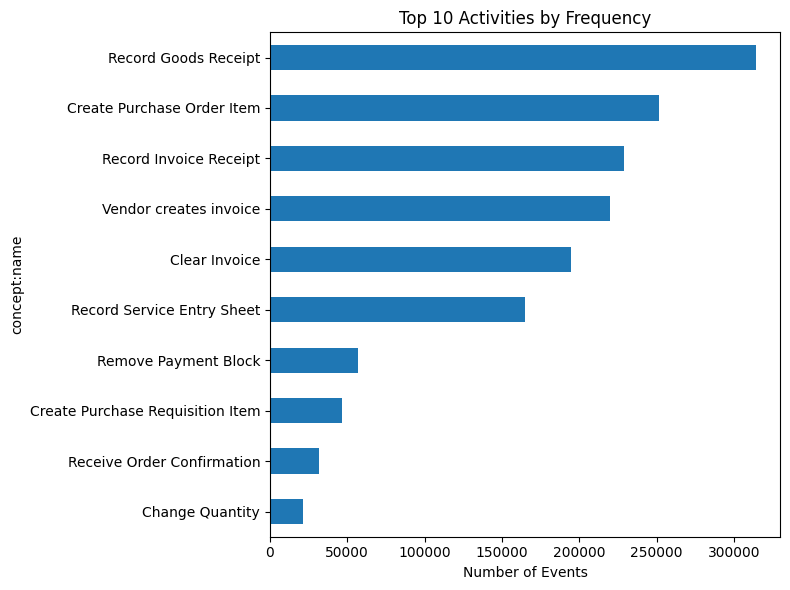

In [ ]:
# Top 10 Activities by Frequency

activity_counts.head(10).plot(kind='barh', figsize=(8, 6))
plt.xlabel('Number of Events')
plt.title('Top 10 Activities by Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
srm_activities = [a for a in event_log['concept:name'].unique() if a.startswith('SRM')]
srm_cases = event_log[event_log['concept:name'].isin(srm_activities)]['case:concept:name'].nunique()
print(f"Number of unique cases involving SRM activities: {srm_cases}")

Number of unique cases involving SRM activities: 1440


**Key insight — A fifth, minor process variant identified (SRM cases):**

The 1,440 unique cases involving SRM activities appear to be a fifth,
minor process variant, additional to the four documented flow types
(3-way with/without GR-based invoicing, 2-way, consignment). These cases
are likely system-generated by SAP's Supplier Relationship Management
module. For a better understanding of the analysis, the four flow types
are described below.

**The four documented flow types**, per the official description of the
[BPI Challenge 2019](https://icpmconference.org/2019/icpm-2019/contests-challenges/bpi-challenge-2019/),
are distinguished by the `case:GR-Based Inv. Verif.` and `case:Goods
Receipt` flags:

1. **3-way matching, invoice after goods receipt** — the goods receipt
   value must match both the invoice receipt value and the value at item
   creation (`GR-Based Inv. Verif.` = True, `Goods Receipt` = True)
2. **3-way matching, invoice before goods receipt** — a goods receipt is
   required, but not GR-based invoicing (`GR-Based Inv. Verif.` = False,
   `Goods Receipt` = True); invoices can be entered before goods arrive,
   but are blocked until delivered — unblocked either manually or by a
   batch process — and only cleared once the goods receipt value matches
3. **2-way matching** — no separate goods receipt is required; the
   invoice value must match the value at item creation directly
   (`GR-Based Inv. Verif.` = False, `Goods Receipt` = False)
4. **Consignment** — no invoice exists at the PO level at all, since this
   is handled in a fully separate process (`Goods Receipt` = True,
   `GR-Based Inv. Verif.` = False, `Item Type` = Consignment)

*Note:* For the upcoming Process Discovery analysis, the 1,440 SRM cases
will be filtered out when discovering the "main" process model. In this
way, a distortion of the dominant flow with a minor pathway is avoided.
The same filtering applies to Conformance Checking: SRM cases would very
likely appear as "deviations" against a model built from the main flow
types, but this reflects a different process variant, not a genuine
compliance deviation. SRM cases remain available in the full dataset for
separate, targeted analysis later.

In [ ]:
# Case duration distribution

case_duration = event_log.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
case_duration['duration_days'] = (case_duration['max'] - case_duration['min']).dt.total_seconds() / (24 * 3600)

print(case_duration['duration_days'].describe())

count    251734.000000
mean         71.524532
std         152.781400
min           0.000000
25%          34.252083
50%          64.044097
75%          98.262500
max       25670.547917
Name: duration_days, dtype: float64


In [ ]:
# Investigating the max value

# idxmax() finds the index (here: case ID) of the row with the maximum
# value in this column — used to identify the case with the longest duration

outlier_case = case_duration['duration_days'].idxmax()
print(f"Case ID: {outlier_case}")
print(event_log[event_log['case:concept:name'] == outlier_case][['concept:name', 'time:timestamp']].sort_values('time:timestamp'))

Case ID: 4507004931_00010
                      concept:name            time:timestamp
118143      Vendor creates invoice 1948-01-26 22:59:00+00:00
118144   Vendor creates debit memo 1948-01-26 22:59:00+00:00
118145  Create Purchase Order Item 2018-01-24 06:30:00+00:00
118146        Record Goods Receipt 2018-01-25 16:43:00+00:00
118147      Record Invoice Receipt 2018-01-26 14:45:00+00:00
118148      Vendor creates invoice 2018-01-26 22:59:00+00:00
118149      Cancel Invoice Receipt 2018-05-07 08:06:00+00:00
118150               Clear Invoice 2018-05-07 08:07:00+00:00
118151      Record Invoice Receipt 2018-05-07 08:09:00+00:00
118152               Clear Invoice 2018-05-09 12:08:00+00:00


In [ ]:
# Check for other suspiciously old timestamps

early_events = event_log[event_log['time:timestamp'].dt.year < 2000]
print(f"Number of events before year 2000: {len(early_events)}")
print(early_events['time:timestamp'].dt.year.value_counts().sort_index())

Number of events before year 2000: 19
time:timestamp
1948    10
1993     9
Name: count, dtype: int64


In [ ]:
# Also check which activities are affected
print(early_events['concept:name'].value_counts())

concept:name
Vendor creates invoice       14
Vendor creates debit memo     5
Name: count, dtype: int64


In [ ]:
# Flag and exclude events with clearly incorrect timestamps (pre-2000)
# Documented finding: 19 events, concentrated in vendor-side activities
# ('Vendor creates invoice', 'Vendor creates debit memo'), likely a
# timestamp parsing/migration artifact affecting externally-sourced data

n_before = len(event_log)
event_log = event_log[event_log['time:timestamp'].dt.year >= 2000]
n_after = len(event_log)

print(f"Removed {n_before - n_after} events with implausible timestamps (pre-2000)")
print(f"Remaining events: {n_after}")

Removed 19 events with implausible timestamps (pre-2000)
Remaining events: 1595904


**Key insight — Implausible pre-2000 timestamps traced to vendor-side
activities:**

19 events out of 1.6 million (0.001%) occurred before the
year 2000 (1948: 10, 1993: 9), both implausible for a 2018 procurement
dataset. Notably, all 19 belong to "Vendor creates invoice" (14) and
"Vendor creates debit memo" (5) — the same two vendor-side activities
flagged earlier for the `NONE` resource pattern. A likely shared cause:
vendor-submitted data may go through different validation/timestamping
logic than internally-generated SAP events, making these two activities
the weakest link for data quality in this log.

*Note:* Given the negligible size (0.001%) and clear implausibility, these
19 events are removed from the dataset. The remaining dataset comprises
1,595,904 events.

In [ ]:
# Missing value check per column

missing = event_log.isnull().sum()
missing_pct = (missing / len(event_log) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_count', ascending=False)

print(missing_summary[missing_summary['missing_count'] > 0])

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []


In [ ]:
# Check for common placeholder values across object/string columns

placeholder_candidates = ['NONE', 'NaN', 'nan', 'NULL', 'null', 'N/A', 'n/a', '', ' ', 'Unknown', 'unknown', '-']

for col in event_log.select_dtypes(include='object').columns:
    found = event_log[col].isin(placeholder_candidates).sum()
    if found > 0:
        print(f"{col}: {found} placeholder-like values found")

User: 399071 placeholder-like values found
org:resource: 399071 placeholder-like values found
case:Spend area text: 16294 placeholder-like values found
case:Sub spend area text: 16294 placeholder-like values found
case:Spend classification text: 16294 placeholder-like values found


In [ ]:
# Which placeholder value is actually appearing?

for col in ['case:Spend area text', 'case:Sub spend area text', 'case:Spend classification text']:
    placeholder_values = event_log[event_log[col].isin(['NONE', 'NaN', 'nan', 'NULL', 'null', 'N/A', 'n/a', '', ' ', 'Unknown', 'unknown', '-'])][col].value_counts()
    print(f"\n{col}:")
    print(placeholder_values)


case:Spend area text:
case:Spend area text
    16294
Name: count, dtype: int64

case:Sub spend area text:
case:Sub spend area text
    16294
Name: count, dtype: int64

case:Spend classification text:
case:Spend classification text
    16294
Name: count, dtype: int64


In [ ]:
# Show the raw repr to see exactly what the empty-looking value is

sample = event_log[event_log['case:Spend area text'].isin(['', ' ', 'NONE', 'NaN', 'nan'])]['case:Spend area text'].iloc[0]
print(repr(sample))

''


In [ ]:
# How many unique cases are affected?

affected_cases = event_log[event_log['case:Spend area text'].isin(['NONE', 'NaN', 'nan', 'NULL', 'null', 'N/A', 'n/a', '', ' ', 'Unknown', 'unknown', '-'])]['case:concept:name'].nunique()
print(f"Unique cases affected: {affected_cases}")

Unique cases affected: 3289


In [ ]:
# Does this correlate with a specific item category / flow type?

affected = event_log[event_log['case:Spend area text'].isin(['NONE', 'NaN', 'nan', 'NULL', 'null', 'N/A', 'n/a', '', ' ', 'Unknown', 'unknown', '-'])]
print(affected['case:Item Category'].value_counts())

case:Item Category
3-way match, invoice before GR    14617
3-way match, invoice after GR      1486
2-way match                         128
Consignment                          63
Name: count, dtype: int64


In [ ]:
total_by_category = event_log['case:Item Category'].value_counts()
affected_by_category = affected['case:Item Category'].value_counts()

# Pandas matches by category label here, not by row position — so this
# stays correct even if the two Series list categories in a different order
# Example: for "2-way match", it computes
# affected_by_category["2-way match"] / total_by_category["2-way match"],
# regardless of which row each value happens to sit in

rate_by_category = (affected_by_category / total_by_category * 100).round(2)
print(rate_by_category.sort_values(ascending=False))

case:Item Category
2-way match                       2.17
3-way match, invoice before GR    1.18
3-way match, invoice after GR     0.47
Consignment                       0.17
Name: count, dtype: float64


**Key insights — Placeholder values confirm existing patterns:**

1. **`User` column**: 399,071 placeholder-like values found — this
   confirms the earlier `NONE` finding rather than revealing something
   new. Together with the 19 removed implausible-timestamp events, it
   matches the original 399,090 `NONE` count exactly (those 19 events
   were all "Vendor creates invoice" / "Vendor creates debit memo," the
   same activities where `NONE` resources cluster)
2. **The three spend-related columns** — `case:Spend area text`,
   `case:Sub spend area text`, `case:Spend classification text` — all
   show exactly 16,294 placeholder values, confirmed as genuine empty
   strings (`''`). The rate varies by `case:Item Category`, from 0.17%
   (`Consignment`) to 2.17% (`2-way match`)

*Note:* Worth investigating during Conformance Checking whether `2-way
match` cases — being structurally simpler, with fewer approval steps —
are more prone to having skipped or less thoroughly entered data.

## 1.4 Data Quality Checks
- Data type check
- Duplicate events
- Timestamp consistency (chronological order within cases)
- Unexpected/rare attribute values

In [ ]:
# Data type check — confirm columns have the expected types before
# proceeding with further quality checks (e.g., time:timestamp must
# be datetime for any date-based analysis to work correctly)

print(event_log.dtypes)

User                                           object
org:resource                                   object
concept:name                                   object
Cumulative net worth (EUR)                    float64
time:timestamp                    datetime64[ns, UTC]
case:Spend area text                           object
case:Company                                   object
case:Document Type                             object
case:Sub spend area text                       object
case:Purchasing Document                       object
case:Purch. Doc. Category name                 object
case:Vendor                                    object
case:Item Type                                 object
case:Item Category                             object
case:Spend classification text                 object
case:Source                                    object
case:Name                                      object
case:GR-Based Inv. Verif.                        bool
case:Item                   

In [ ]:
# Duplicate events

n_duplicates = event_log.duplicated().sum()
print(f"Fully duplicate rows: {n_duplicates}")

Fully duplicate rows: 132748


In [ ]:
# Duplicate events in percent

pct_duplicates = n_duplicates / len(event_log) * 100
print(f"Percentage of fully duplicate rows: {pct_duplicates:.2f}%")

Percentage of fully duplicate rows: 8.32%


In [ ]:
# Which activities are most affected?

# keep=False flags ALL copies of a duplicate row, including the first
# occurrence — not just the "extra" ones; this lets us see the full
# group of identical rows together, rather than losing the original

duplicate_rows = event_log[event_log.duplicated(keep=False)]

print(duplicate_rows['concept:name'].value_counts().head(10))

concept:name
Record Service Entry Sheet             147296
Record Goods Receipt                    16770
Clear Invoice                            1140
Change Quantity                           332
Record Invoice Receipt                     76
Cancel Goods Receipt                       73
Change Price                               44
Change Delivery Indicator                  32
Remove Payment Block                       28
SRM: In Transfer to Execution Syst.        14
Name: count, dtype: int64


In [ ]:
# Are duplicates concentrated in batch resources vs. human resources?

print(duplicate_rows['org:resource'].str.startswith('batch_').value_counts())

org:resource
False    154860
True      10961
Name: count, dtype: int64


In [ ]:
# How many unique cases are affected?

print(f"Unique cases with duplicates: {duplicate_rows['case:concept:name'].nunique()}")

Unique cases with duplicates: 4955


In [ ]:
# Find the case with the most duplicate rows

# value_counts() counts how many duplicate rows each case has;
# idxmax() then returns the index (here: case ID) with the highest count

top_dup_case = duplicate_rows['case:concept:name'].value_counts().idxmax()
print(f"Case with most duplicates: {top_dup_case}")

case_detail = event_log[event_log['case:concept:name'] == top_dup_case].sort_values('time:timestamp')
print(f"Total events in this case: {len(case_detail)}")
print(case_detail[['concept:name', 'time:timestamp', 'org:resource']].to_string())

Case with most duplicates: 4507013227_00001
Total events in this case: 509
                      concept:name            time:timestamp org:resource
292771  Create Purchase Order Item 2018-03-01 10:29:00+00:00     user_116
292780  Record Service Entry Sheet 2018-03-01 10:29:00+00:00         NONE
292779  Record Service Entry Sheet 2018-03-01 10:29:00+00:00         NONE
292778  Record Service Entry Sheet 2018-03-01 10:29:00+00:00         NONE
292777  Record Service Entry Sheet 2018-03-01 10:29:00+00:00         NONE
292781  Record Service Entry Sheet 2018-03-01 10:29:00+00:00         NONE
292775  Record Service Entry Sheet 2018-03-01 10:29:00+00:00         NONE
292774  Record Service Entry Sheet 2018-03-01 10:29:00+00:00         NONE
292773  Record Service Entry Sheet 2018-03-01 10:29:00+00:00         NONE
292772  Record Service Entry Sheet 2018-03-01 10:29:00+00:00         NONE
292776  Record Service Entry Sheet 2018-03-01 10:29:00+00:00         NONE
292794  Record Service Entry Sheet 20

**Key insight — High-multiplicity case traced to recurring service
contracts:**

The identified top case with the most duplicates,
`4507013227_00001`, contains 509 events, including multiple genuinely
distinct "Record Service Entry Sheet" events sharing identical timestamps
and `NONE` resources. This pattern is consistent with recurring service
contracts (e.g., monthly billing), where the flat XES export lacks
distinct document IDs per service instance. This strongly suggests these
are genuinely separate real-world service transactions, not data errors.
Therefore, the rows are not deduplicated, and the multiple real objects
(here, multiple Service Entry Sheet documents) are kept as-is and flagged
for deeper investigation in the planned **object-centric process mining
(OCPM) extension** (see README → Planned Extensions).

In [ ]:
# Chronological order check per case

# groupby().apply() runs is_sorted() separately per case, not once for
# the whole dataset — needed because "sorted" only makes sense within
# a single case's own event sequence

def is_sorted(group):
    return group['time:timestamp'].is_monotonic_increasing

case_sorted = event_log.groupby('case:concept:name').apply(is_sorted, include_groups=False)

# ~ flips True/False, so this counts cases where is_sorted() returned False

n_unsorted = (~case_sorted).sum()
print(f"Cases with out-of-order timestamps: {n_unsorted} out of {case_sorted.shape[0]}")

Cases with out-of-order timestamps: 0 out of 251734


**Key insight — Chronological ordering confirmed across all cases:**

All 251,734 cases happen in correct chronological order (0 violations).
Combined with the duplicate-timestamp finding above, this confirms that
timestamp *values* are reliable for event sequencing, even where multiple
genuinely distinct events share an identical timestamp.

## 1.5 Cleaning
- Handle any missing/malformed values identified in Step 1.4
- Standardize column names/types (e.g., ensure timestamps are datetime)
- Filter out any clearly invalid records (document + justify any exclusions)

In [ ]:
# Confirm starting state: the 19 pre-2000 events (found and removed in
# Section 1.3) are indeed absent before proceeding with further cleaning

n_pre_2000 = (event_log['time:timestamp'].dt.year < 2000).sum()
print(f"Events before year 2000: {n_pre_2000}")
print(f"Current event count: {len(event_log)}")

assert n_pre_2000 == 0, "Pre-2000 events found — Section 1.3's removal may not have run"
assert len(event_log) == 1595904, "Unexpected event count — check Section 1.3 execution"

Events before year 2000: 0
Current event count: 1595904


*Note:* This section builds on the cleaned dataset from Section 1.3
(1,595,904 events, after removing 19 events with implausible pre-2000
timestamps). The check above confirms this starting state before
proceeding with further data cleaning.

In [ ]:
# Create a time period column (YYYY-MM) to check for further timestamp issues

event_log['event_month'] = event_log['time:timestamp'].dt.to_period('M')
print(event_log['event_month'].value_counts().sort_index())

event_month
2001-01         1
2001-02         2
2001-04        13
2001-06         4
2001-07         2
2008-06        45
2015-03         1
2015-11         1
2015-12         1
2016-01         1
2016-02         1
2016-04         2
2016-05         1
2016-11         1
2017-01        13
2017-02         3
2017-03         4
2017-04         9
2017-05         7
2017-06         3
2017-07         3
2017-08         7
2017-09         7
2017-10         8
2017-11        22
2017-12       137
2018-01     73474
2018-02    103959
2018-03    139088
2018-04    133348
2018-05    146397
2018-06    143507
2018-07    142436
2018-08    137400
2018-09    140671
2018-10    147964
2018-11    142316
2018-12     99908
2019-01     45128
2019-02         2
2019-04         2
2019-10         1
2019-12         2
2020-04         2
Freq: M, Name: count, dtype: int64


/tmp/ipykernel_996/1239537328.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  event_log['event_month'] = event_log['time:timestamp'].dt.to_period('M')


In [ ]:
# Classify cases by whether they fall within 2018

case_time_range = event_log.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])

def classify_case(row):
    start_2018 = row['min'].year == 2018
    end_2018 = row['max'].year == 2018
    if start_2018 and end_2018:
        return 'both_2018'
    elif start_2018 or end_2018:
        return 'partial_2018'
    else:
        return 'neither_2018'

case_time_range['type'] = case_time_range.apply(classify_case, axis=1)
print(case_time_range['type'].value_counts())
print((case_time_range['type'].value_counts(normalize=True) * 100).round(2))

type
both_2018       218828
partial_2018     32678
neither_2018       228
Name: count, dtype: int64
type
both_2018       86.93
partial_2018    12.98
neither_2018     0.09
Name: proportion, dtype: float64


**Key insight — Cross-validated against Kim, Ko & Lee (2019):**

This dataset's finding that 86.93% of all cases started and ended in 2018
closely matches the corresponding figure (~87%) reported by
[Kim, Ko & Lee (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Student-Submission-3.pdf),
providing independent confirmation of this finding.

In [ ]:
# Investigation of partial_2018

partial_cases = case_time_range[case_time_range['type'] == 'partial_2018'].copy()
partial_cases['min_year'] = partial_cases['min'].dt.year
partial_cases['max_year'] = partial_cases['max'].dt.year

other_years = partial_cases.apply(
    lambda row: row['min_year'] if row['min_year'] != 2018 else row['max_year'], axis=1
)
print(other_years.value_counts().sort_index())

2001       14
2008       45
2015        1
2016        2
2017      162
2019    32452
2020        2
Name: count, dtype: int64


In [ ]:
# Quantify the full anomalous scope, check if isolated or whole-case
# Decision: Event-level removal or case-level removal

# For each case, flag it as anomalous if its earliest OR latest event
# falls outside 2018/2019 — lambda defines this check inline, and
# apply(axis=1) runs it once per case (row)

anomalous_case_ids = case_time_range[
    (case_time_range['type'] == 'neither_2018') |
    ((case_time_range['type'] == 'partial_2018') &
     (case_time_range.apply(lambda row: row['min'].year not in [2018, 2019] or row['max'].year not in [2018, 2019], axis=1)))
].index

print(f"Total anomalous cases: {len(anomalous_case_ids)}")

anomalous_events_check = event_log[event_log['case:concept:name'].isin(anomalous_case_ids)]
events_per_case = anomalous_events_check.groupby('case:concept:name').size()
anomalous_events_per_case = anomalous_events_check[
    (anomalous_events_check['time:timestamp'].dt.year < 2018) |
    (anomalous_events_check['time:timestamp'].dt.year > 2019)
].groupby('case:concept:name').size()

comparison = pd.DataFrame({
    'total_events': events_per_case,
    'anomalous_events': anomalous_events_per_case
}).fillna(0)
comparison['pct_anomalous'] = (comparison['anomalous_events'] / comparison['total_events'] * 100).round(1)

print(comparison['pct_anomalous'].describe())

Total anomalous cases: 454
count    454.000000
mean       8.836123
std        9.332725
min        0.000000
25%        0.000000
50%        4.400000
75%       20.000000
max       33.300000
Name: pct_anomalous, dtype: float64


**Key insight — Implausible-timestamp removal scoped to events, not whole
cases:**

The implausible events outside 2018–2019 belong to 454 cases but
affect on average only 8.8% of a case's events (max 33.3%). This is
consistent with the earlier finding that "Vendor creates invoice" and
"Vendor creates debit memo" — the same vendor-side activities flagged for
`NONE` resources and the pre-2000 timestamps — are the likely source,
suggesting a general data export/anonymization artifact affecting these
specific vendor-submitted events rather than the cases as a whole. As a
result, only the anomalous events are removed, not whole cases.

In [ ]:
# Second pass: remove remaining events with implausible timestamps
# (outside 2018-2019), identified via the case-level investigation above

n_before = len(event_log)
event_log = event_log[
    (event_log['time:timestamp'].dt.year >= 2018) &
    (event_log['time:timestamp'].dt.year <= 2019)
]
n_after = len(event_log)

print(f"Removed {n_before - n_after} additional events with implausible timestamps")
print(f"Remaining events: {n_after}")

Removed 301 additional events with implausible timestamps
Remaining events: 1595603


In [ ]:
print(f"Current event_log size: {len(event_log)}")
print(f"Current unique cases: {event_log['case:concept:name'].nunique()}")
print(f"Difference from original (1,595,923): {1595923 - len(event_log)}")
print(event_log['time:timestamp'].dt.year.value_counts().sort_index())

Current event_log size: 1595603
Current unique cases: 251734
Difference from original (1,595,923): 320
time:timestamp
2018    1550468
2019      45135
Name: count, dtype: int64


**Key insight — Cleaned dataset summary:**

After cleaning, the dataset comprises 1,595,603 events across 251,734
cases (320 events with implausible timestamps removed in total across two
passes — 19 initially, plus 301 more identified through case-level
investigation above). All other identified data quality patterns were
investigated and kept as legitimate, documented characteristics of the
dataset, not treated as errors:

- `NONE` resources (399,090 rows, 25.0% of events)
- Empty spend-classification values (16,294 genuine empty strings, 1.3%
  of cases)
- Duplicate-looking rows (132,748 rows, 8.31%, genuine real-world service
  events)

## 1.6 Segmentation Setup
- Add/verify item category column (3-way w/ GR-based invoicing, 3-way
  w/o, 2-way, consignment)
- Add/verify vendor, company (subsidiary), and time period columns

In [ ]:
# Verify item category (the four flow types)

print(event_log['case:Item Category'].value_counts())

case:Item Category
3-way match, invoice before GR    1234496
3-way match, invoice after GR      319143
Consignment                         36083
2-way match                          5881
Name: count, dtype: int64


In [ ]:
pct = (event_log['case:Item Category'].value_counts() / len(event_log) * 100).round(2)
print(pct)

case:Item Category
3-way match, invoice before GR    77.37
3-way match, invoice after GR     20.00
Consignment                        2.26
2-way match                        0.37
Name: count, dtype: float64


In [ ]:
# Verify vendor column

n_vendors = event_log['case:Vendor'].nunique()
print(f"Number of unique vendors: {n_vendors}")

Number of unique vendors: 1975


In [ ]:
# Verify company (subsidiary) column

n_companies = event_log['case:Company'].nunique()
print(f"Number of unique companies (subsidiaries): {n_companies}")

Number of unique companies (subsidiaries): 4


In [ ]:
print(event_log.groupby('case:Company')['case:concept:name'].nunique())

case:Company
companyID_0000    250686
companyID_0001         2
companyID_0002         2
companyID_0003      1044
Name: case:concept:name, dtype: int64


In [ ]:
pct = (event_log['case:Company'].value_counts() / len(event_log) * 100).round(2)
print(pct)

case:Company
companyID_0000    99.63
companyID_0003     0.37
companyID_0001     0.00
companyID_0002     0.00
Name: count, dtype: float64


**Key insight — Company distribution heavily skewed toward one entity:**

The dataset comprises 4 different companies (the dataset description
states the log includes some of the 60 subsidiaries of the Dutch parent
company; a small number of distinct companies appearing in the data is
plausible, though this has not been independently verified against
another source). The distribution is heavily skewed:

- `companyID_0000` accounts for 99.63% of cases (250,686 of 251,734)
- `companyID_0003` accounts for 0.37% of cases (1,044)
- `companyID_0001` and `companyID_0002` each have just 2 cases —
  essentially negligible

*Note:* A subsidiary-level segmented analysis will only be statistically
meaningful for `companyID_0000` and `companyID_0003`, given the
negligible case counts for the other two.

In [ ]:
# Create a time period column (YYYY-MM)

event_log['event_month'] = event_log['time:timestamp'].dt.to_period('M')
print(event_log['event_month'].value_counts().sort_index())

event_month
2018-01     73474
2018-02    103959
2018-03    139088
2018-04    133348
2018-05    146397
2018-06    143507
2018-07    142436
2018-08    137400
2018-09    140671
2018-10    147964
2018-11    142316
2018-12     99908
2019-01     45128
2019-02         2
2019-04         2
2019-10         1
2019-12         2
Freq: M, Name: count, dtype: int64


/tmp/ipykernel_996/2460977496.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  event_log['event_month'] = event_log['time:timestamp'].dt.to_period('M')


**Key insight — Segmentation columns confirmed:**

All four segmentation dimensions are present and usable on the cleaned dataset (1,595,603 events, 251,734 cases): `case:Item Category` (4 flow types,
77.37%/20.00%/2.26%/0.37%), `case:Vendor` (1,975 unique vendors across
the full dataset), `case:Company` (4 subsidiaries, heavily skewed toward
`companyID_0000` at 99.63%), and `event_month` (time period, now cleanly
limited to 2018–2019 following Section 1.5's cleaning). These are the
final segmentation figures for this project going forward.

*Note:* Downstream notebooks (4 onward) exclude SRM cases (1,440 cases)
before vendor-level analysis, giving a reduced count of 1,674 unique
vendors — the figure actually used throughout Notebooks 4–7. Both counts
are correct; they reflect different scopes (full dataset vs. SRM-excluded).

## 1.7 Save Processed Output
- Export cleaned event log
- Final notebook summary

In [ ]:
output_path = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/BPI_2019_cleaned.parquet"

# Parquet doesn't support Period dtype directly — convert event_month
# to string before saving, can be converted back to Period on reload if needed
event_log_to_save = event_log.copy()
event_log_to_save['event_month'] = event_log_to_save['event_month'].astype(str)

event_log_to_save.to_parquet(output_path, index=False)
print(f"Saved cleaned dataset to: {output_path}")

Saved cleaned dataset to: /content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/BPI_2019_cleaned.parquet


In [ ]:
# Reload and confirm it matches

verify_df = pd.read_parquet(output_path)
print(f"Reloaded shape: {verify_df.shape}")
print(f"Matches original: {verify_df.shape == event_log_to_save.shape}")
print(verify_df.dtypes)

Reloaded shape: (1595603, 22)
Matches original: True
User                                           object
org:resource                                   object
concept:name                                   object
Cumulative net worth (EUR)                    float64
time:timestamp                    datetime64[ns, UTC]
case:Spend area text                           object
case:Company                                   object
case:Document Type                             object
case:Sub spend area text                       object
case:Purchasing Document                       object
case:Purch. Doc. Category name                 object
case:Vendor                                    object
case:Item Type                                 object
case:Item Category                             object
case:Spend classification text                 object
case:Source                                    object
case:Name                                      object
case:GR-Based Inv. Verif.    

In [ ]:
# Final notebook summary

print("="*50)
print("NOTEBOOK 1 COMPLETE — Data Loading & Cleaning")
print("="*50)
print(f"Original dataset: 1,595,923 events, 251,734 cases")
print(f"Final cleaned dataset: {len(event_log)} events, {event_log['case:concept:name'].nunique()} cases")
print(f"Events removed: {1595923 - len(event_log)} (320 total, implausible timestamps)")
print(f"Saved to: {output_path}")

NOTEBOOK 1 COMPLETE — Data Loading & Cleaning
Original dataset: 1,595,923 events, 251,734 cases
Final cleaned dataset: 1595603 events, 251734 cases
Events removed: 320 (320 total, implausible timestamps)
Saved to: /content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/BPI_2019_cleaned.parquet


In [ ]:
# Final cell: confirms a clean, complete run of this notebook

import datetime
from zoneinfo import ZoneInfo

cet_time = datetime.datetime.now(ZoneInfo("Europe/Berlin"))

print("=" * 50)
print(f"Notebook executed successfully, top to bottom.")
print(f"Run completed: {cet_time.strftime('%Y-%m-%d %H:%M %Z')}")
print("=" * 50)

Notebook executed successfully, top to bottom.
Run completed: 2026-09-10 20:17 CEST
